# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Salzabila Triana Said
- Email: strianasaid@gmail.com
- Id Dicoding: zalana9

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Dataset ini berisi data siswa Jaya Jaya Institut mulai dari kondisi sosio-ekonomi saat pendaftaran hingga performa akademik pada semester 1 dan 2. Kolom target `Status` memiliki tiga kelas: `Dropout`, `Enrolled` (masih aktif), dan `Graduate` (lulus).

## Data Understanding

In [3]:
print("Jumlah baris dan kolom:", df.shape)
df.info()

Jumlah baris dan kolom: (4424, 37)
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [5]:
print("Jumlah missing value per kolom:")
print(df.isna().sum().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

Jumlah missing value per kolom:
0

Jumlah baris duplikat: 0


Pada tahap ini, saya memeriksa kualitas data secara umum. Hasilnya, dataset tidak memiliki missing value maupun baris duplikat, sehingga tidak diperlukan proses pembersihan data yang berat pada tahap selanjutnya.

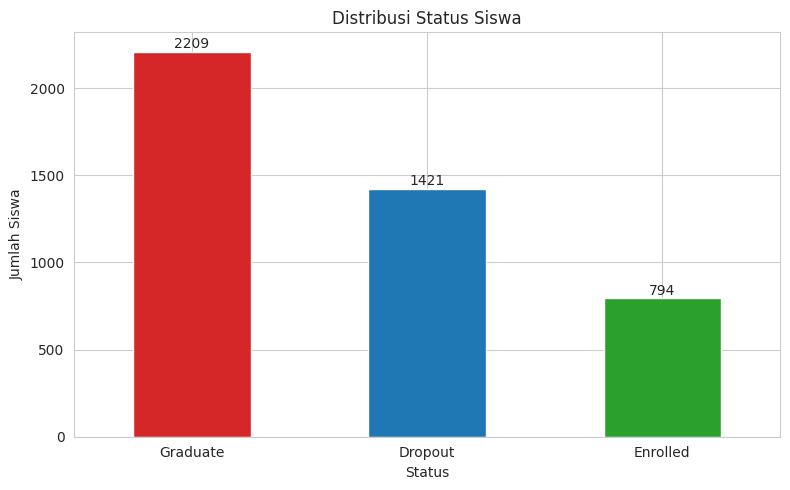

Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: count, dtype: float64


In [6]:
status_counts = df['Status'].value_counts()
ax = status_counts.plot(kind='bar', color=['#d62728', '#1f77b4', '#2ca02c'])
plt.title('Distribusi Status Siswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Siswa')
plt.xticks(rotation=0)
for i, v in enumerate(status_counts):
    ax.text(i, v + 20, str(v), ha='center')
plt.tight_layout()
plt.savefig('status_distribution.png', dpi=120)
plt.show()
print(status_counts / status_counts.sum() * 100)

Grafik di atas menunjukkan bahwa dari 4.424 siswa, sekitar 32% (1.421 siswa) berstatus Dropout, 50% Graduate, dan 18% masih Enrolled. Proporsi dropout yang cukup tinggi ini menegaskan urgensi bagi Jaya Jaya Institut untuk memiliki sistem deteksi dini.

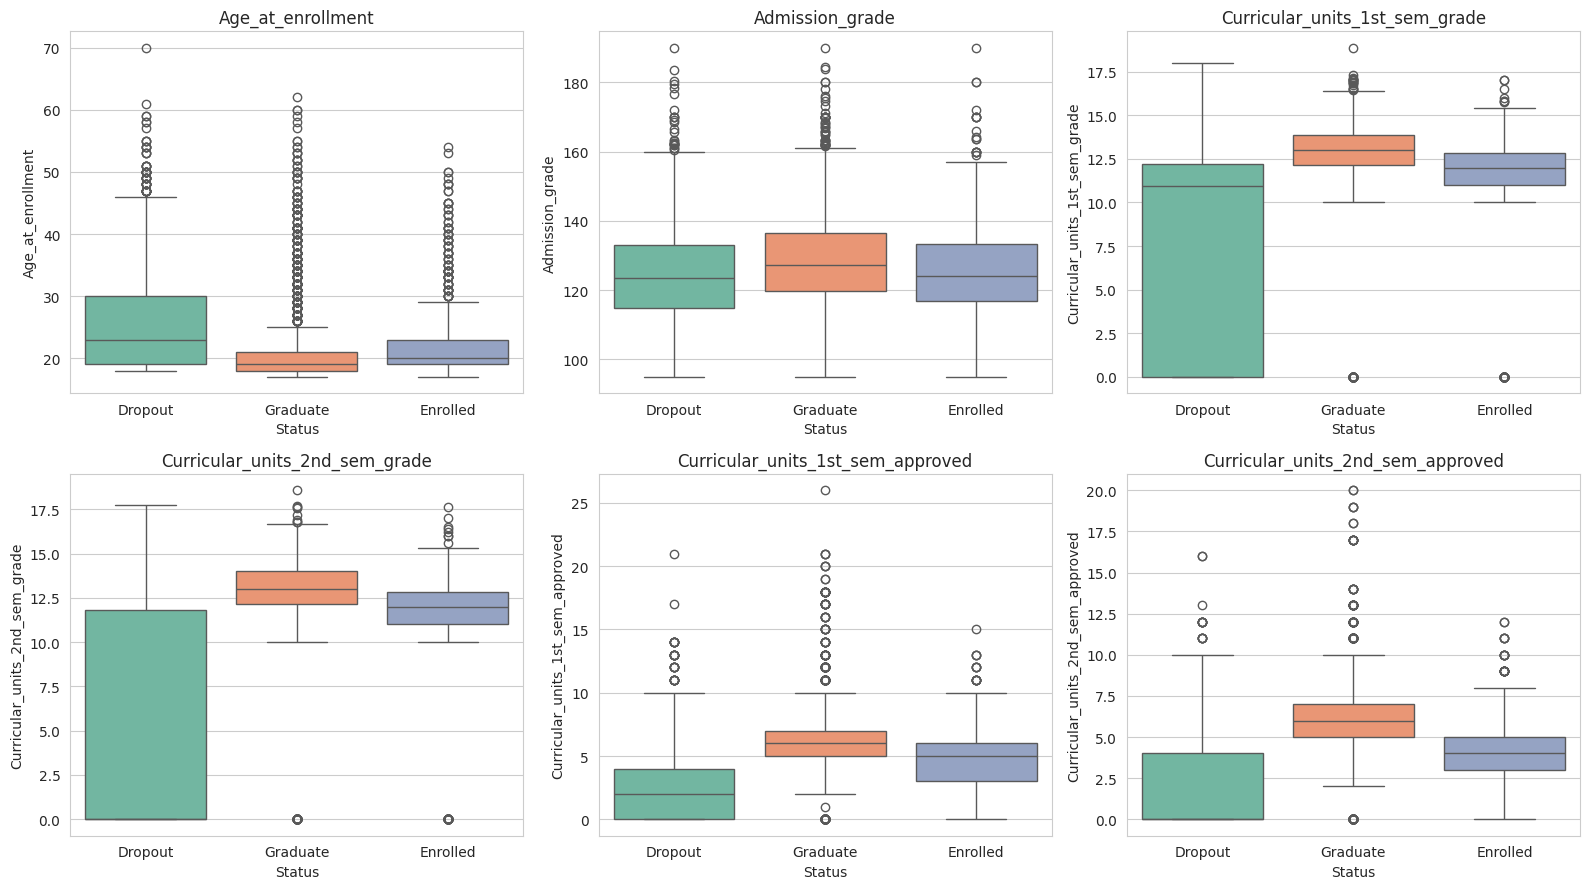

In [7]:
numeric_cols_of_interest = ['Age_at_enrollment', 'Admission_grade',
                             'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                             'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_cols_of_interest):
    sns.boxplot(data=df, x='Status', y=col, ax=ax, palette='Set2')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('numeric_by_status.png', dpi=120)
plt.show()

Beberapa insight awal dari visualisasi di atas:
- Siswa yang Dropout cenderung memiliki jumlah mata kuliah yang **disetujui/lulus** (approved) jauh lebih rendah pada semester 1 dan 2 dibanding siswa Graduate maupun Enrolled.
- Nilai rata-rata mata kuliah (grade) semester 1 dan 2 pada kelompok Dropout juga jauh lebih rendah, bahkan banyak yang bernilai 0 (kemungkinan tidak mengikuti evaluasi sama sekali).
- Nilai admission grade tidak menunjukkan perbedaan yang terlalu signifikan antar kelompok, mengindikasikan performa akademik saat kuliah lebih prediktif dibanding nilai masuk.

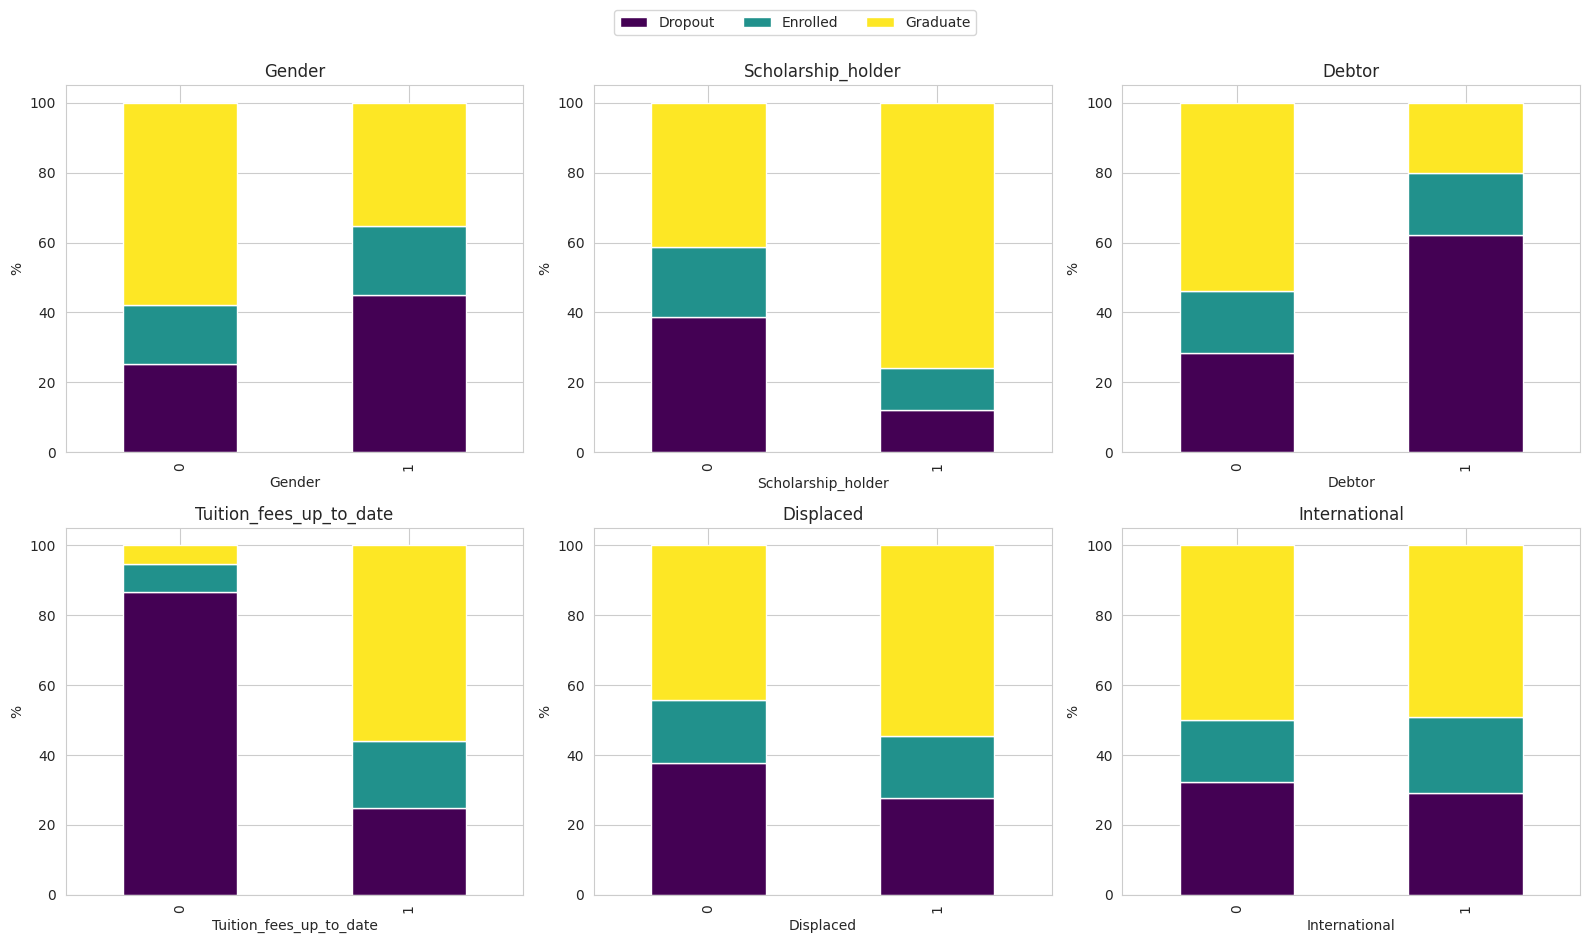

In [8]:
categorical_flags = ['Gender', 'Scholarship_holder', 'Debtor', 'Tuition_fees_up_to_date',
                      'Displaced', 'International']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), categorical_flags):
    ct = pd.crosstab(df[col], df['Status'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', legend=False)
    ax.set_title(col)
    ax.set_ylabel('%')
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.savefig('categorical_by_status.png', dpi=120)
plt.show()

Grafik proporsi status berdasarkan atribut kategorikal/biner menunjukkan bahwa siswa yang berstatus **debtor** (memiliki tunggakan) dan yang pembayaran SPP-nya **tidak up to date** memiliki proporsi dropout yang jauh lebih tinggi dibanding siswa lain. Penerima beasiswa (scholarship holder) sebaliknya menunjukkan proporsi dropout yang jauh lebih rendah, mengindikasikan bahwa faktor finansial berperan penting terhadap keputusan siswa untuk berhenti kuliah.

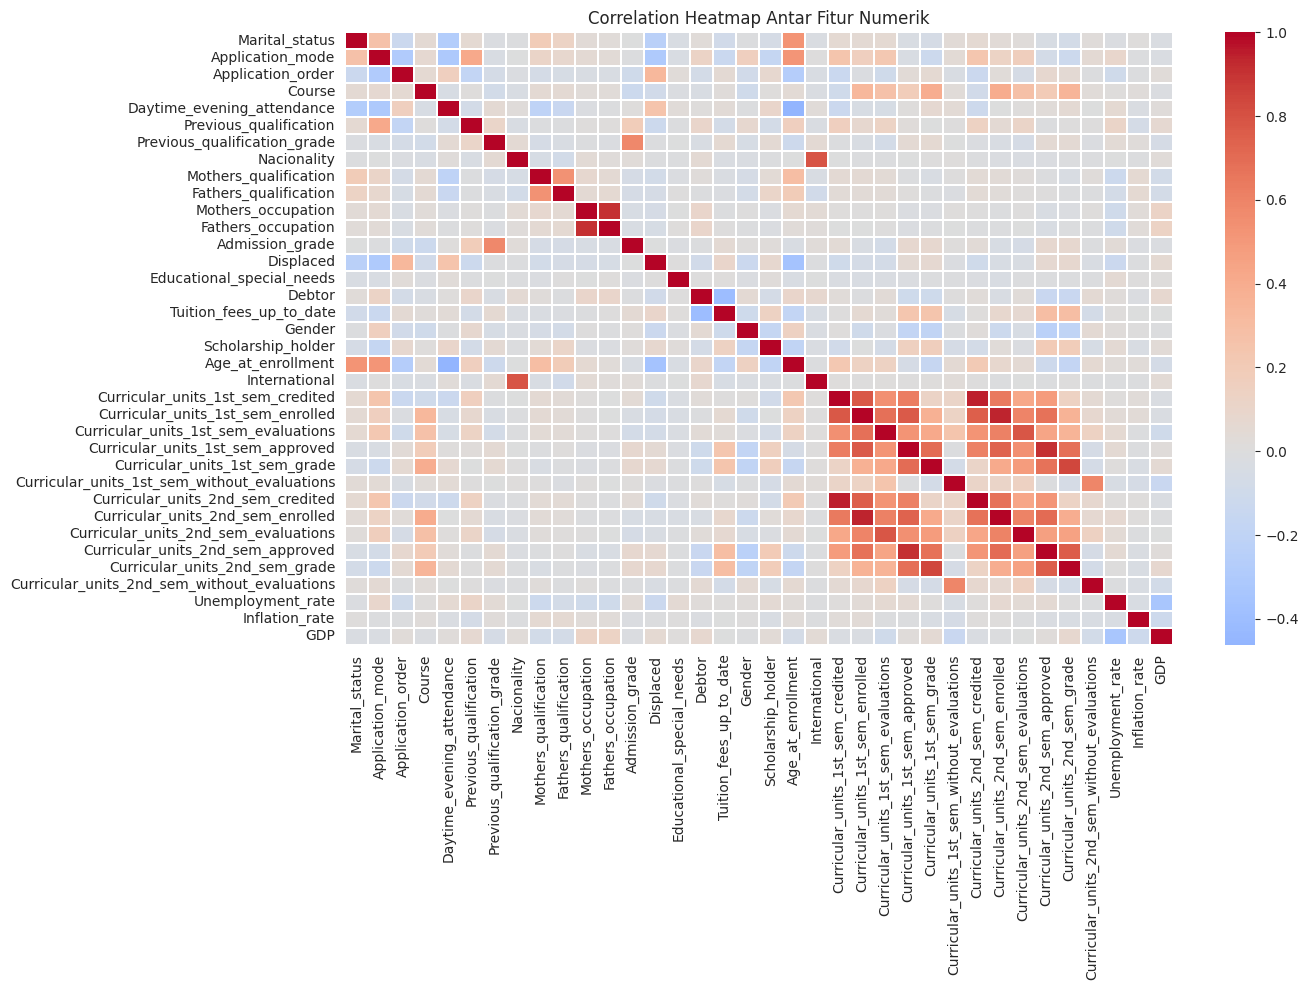

In [9]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap Antar Fitur Numerik')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

Peta korelasi ini membantu melihat fitur-fitur yang saling berhubungan kuat, misalnya antar variabel `Curricular_units` semester 1 dan 2, yang nantinya menjadi kandidat fitur penting dalam pemodelan.

## Data Preparation / Preprocessing

In [10]:
# Encode target: Dropout=0, Enrolled=1, Graduate=2
status_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Status_encoded'] = df['Status'].map(status_mapping)

X = df.drop(columns=['Status', 'Status_encoded'])
y = df['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3539, 36)
Test shape: (885, 36)


Seluruh fitur pada dataset ini sudah berbentuk numerik (kolom kategorikal telah dikodekan menjadi angka oleh penyedia data), sehingga tidak diperlukan encoding tambahan. Data dibagi menjadi 80% data latih dan 20% data uji dengan stratifikasi berdasarkan kelas target agar proporsi tiap kelas tetap terjaga.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'model/scaler.pkl')
print("Scaler disimpan.")

Scaler disimpan.


Standarisasi (StandardScaler) diterapkan pada fitur numerik agar setiap fitur memiliki skala yang sebanding. Hal ini penting terutama untuk model seperti Logistic Regression yang sensitif terhadap skala fitur.

## Modeling

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression - F1 (macro):", f1_score(y_test, y_pred_lr, average='macro'))

Logistic Regression - Accuracy: 0.768361581920904
Logistic Regression - F1 (macro): 0.682601247658837


In [13]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest - Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest - F1 (macro):", f1_score(y_test, y_pred_rf, average='macro'))

Random Forest - Accuracy: 0.7728813559322034
Random Forest - F1 (macro): 0.6978337488115237


Pada tahap ini saya melatih dua model klasifikasi: **Logistic Regression** sebagai baseline yang sederhana dan mudah diinterpretasi, serta **Random Forest** yang mampu menangkap pola non-linear antar fitur. Parameter `class_weight='balanced'` digunakan pada Random Forest untuk mengurangi bias terhadap kelas mayoritas (Graduate).

In [14]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
                     param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1 macro:", grid.best_score_)

best_rf = grid.best_estimator_

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 macro: 0.7141146266630426


Untuk mendapatkan performa terbaik, dilakukan hyperparameter tuning menggunakan `GridSearchCV` dengan skema 3-fold cross validation pada Random Forest, dioptimasi berdasarkan metrik F1-macro (karena distribusi kelas tidak seimbang).

## Evaluation

In [15]:
y_pred_best = best_rf.predict(X_test_scaled)
print("=== Classification Report (Random Forest - Tuned) ===")
print(classification_report(y_test, y_pred_best, target_names=['Dropout', 'Enrolled', 'Graduate']))

=== Classification Report (Random Forest - Tuned) ===
              precision    recall  f1-score   support

     Dropout       0.83      0.69      0.75       284
    Enrolled       0.46      0.56      0.50       159
    Graduate       0.83      0.86      0.85       442

    accuracy                           0.75       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885



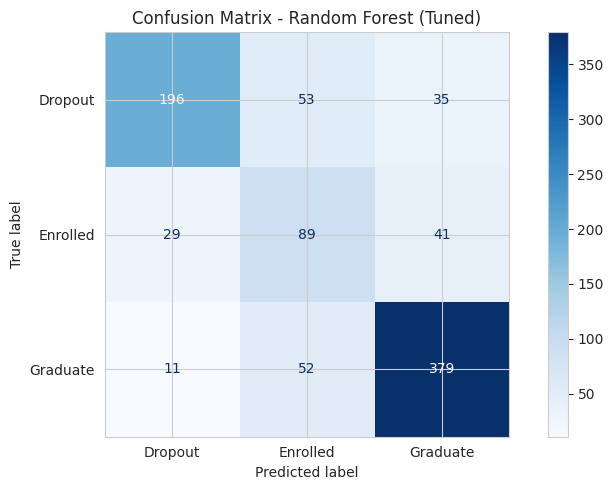

In [16]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

Confusion matrix menunjukkan bahwa model cukup baik dalam mengenali siswa berstatus Dropout dan Graduate. Sebagian kesalahan klasifikasi terjadi antara kelas Enrolled dan Graduate/Dropout, yang masuk akal karena siswa yang masih aktif (Enrolled) secara alami memiliki karakteristik yang berada di antara dua kelas lainnya.

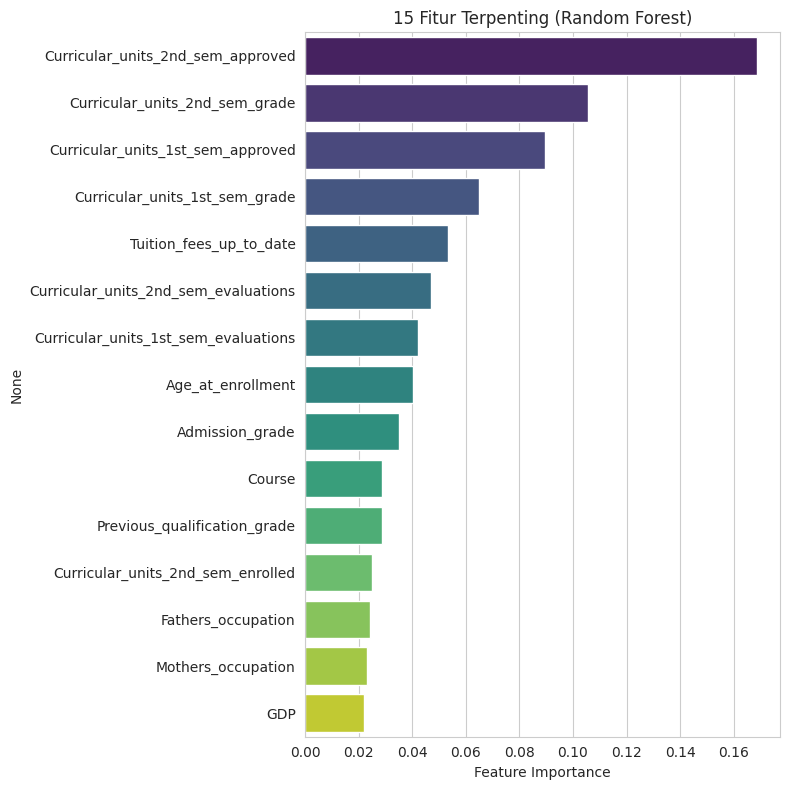

Curricular_units_2nd_sem_approved       0.168913
Curricular_units_2nd_sem_grade          0.105423
Curricular_units_1st_sem_approved       0.089699
Curricular_units_1st_sem_grade          0.065021
Tuition_fees_up_to_date                 0.053341
Curricular_units_2nd_sem_evaluations    0.047057
Curricular_units_1st_sem_evaluations    0.042125
Age_at_enrollment                       0.040332
Admission_grade                         0.034912
Course                                  0.028749
Previous_qualification_grade            0.028558
Curricular_units_2nd_sem_enrolled       0.025029
Fathers_occupation                      0.024037
Mothers_occupation                      0.022987
GDP                                     0.021851
dtype: float64

In [17]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(15)

plt.figure(figsize=(8, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('15 Fitur Terpenting (Random Forest)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
top_features

Fitur-fitur yang paling berpengaruh terhadap prediksi status siswa umumnya berkaitan dengan **performa akademik semester 1 dan 2** (jumlah mata kuliah yang disetujui/lulus dan nilai rata-rata), diikuti oleh faktor finansial seperti `Tuition_fees_up_to_date` dan `Debtor`, serta `Age_at_enrollment` dan `Admission_grade`. Insight ini konsisten dengan temuan pada tahap eksplorasi data sebelumnya dan menjadi dasar bagi rekomendasi action items.

In [18]:
joblib.dump(best_rf, 'model/rf_dropout_model.pkl')
joblib.dump(list(X.columns), 'model/feature_columns.pkl')
joblib.dump(status_mapping, 'model/status_mapping.pkl')
print("Model, daftar fitur, dan mapping status berhasil disimpan ke folder 'model/'.")

Model, daftar fitur, dan mapping status berhasil disimpan ke folder 'model/'.


Model Random Forest terbaik beserta scaler dan daftar fitur disimpan ke dalam folder `model/` agar dapat digunakan kembali oleh prototype sistem machine learning (`app.py`) tanpa perlu melatih ulang model.